<a href="https://colab.research.google.com/github/sandhyasaki511-del/Data-analytics-project-1/blob/main/PROJECT_2_customersegmentation_(data_analytics).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [3]:
data =pd.read_csv('/content/customers.csv')

In [ ]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [5]:
data.shape

(200, 5)

In [6]:
print("Number of Rows",data.shape[0])
print("Number of columns",data.shape[1])

Number of Rows 200
Number of columns 5


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
data.isnull()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
195,False,False,False,False,False
196,False,False,False,False,False
197,False,False,False,False,False
198,False,False,False,False,False


In [9]:
data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [10]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [12]:
x = data[['Annual Income (k$)',
       'Spending Score (1-100)']]

In [13]:
x

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [14]:
from sklearn.cluster import KMeans

In [15]:
k_means=KMeans()
k_means.fit(x)


KMeans()

In [16]:
k_means=KMeans(n_clusters=5)
k_means.fit_predict(x)

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 0,
       4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [17]:
wcss=[]
for i in range(1,11):
  k_means=KMeans(n_clusters=i)
  k_means.fit(x)
  wcss.append(k_means.inertia_)

In [18]:
wcss

[269981.28000000014,
 183811.2827701642,
 106348.37306211119,
 73880.64496247198,
 66790.25561457996,
 38858.959975143895,
 30273.394312070028,
 27708.08442384324,
 28129.546518759023,
 21604.489849088874]

In [19]:
import matplotlib.pyplot as plt

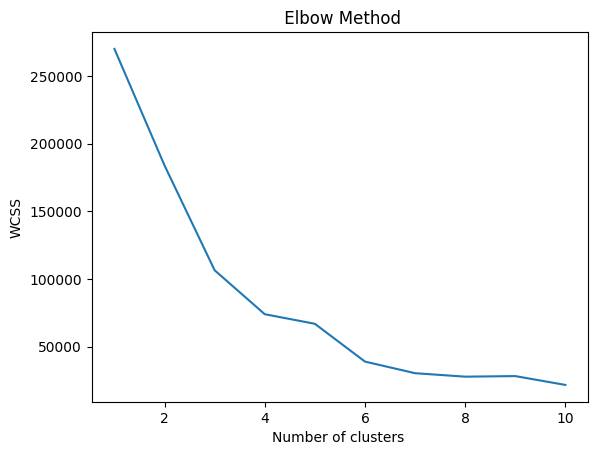

In [20]:
plt.plot(range(1,11),wcss)
plt.title(" Elbow Method")
plt.xlabel("Number of clusters ")
plt.ylabel("WCSS")
plt.show()

In [21]:
x = data[['Annual Income (k$)',
       'Spending Score (1-100)']]

In [23]:
k_means = KMeans(n_clusters=5,random_state=42)
y_means = k_means.fit_predict(x)

In [24]:
y_means

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

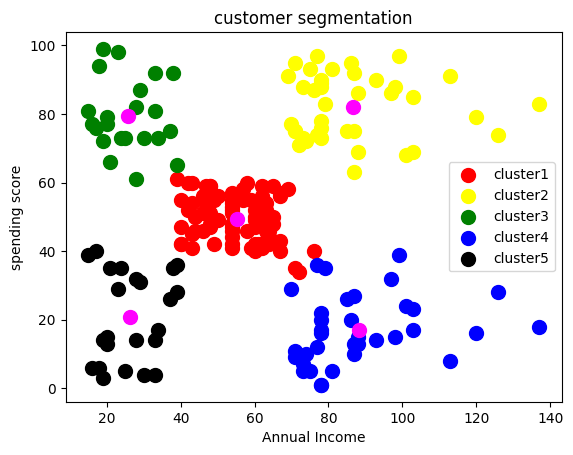

In [44]:
plt.scatter(x.iloc[y_means==0,0], x.iloc[y_means==0,1], s=100, c='red', label="cluster1")
plt.scatter(x.iloc[y_means==1,0], x.iloc[y_means==1,1], s=100, c='yellow', label="cluster2")
plt.scatter(x.iloc[y_means==2,0], x.iloc[y_means==2,1], s=100, c='green', label="cluster3")
plt.scatter(x.iloc[y_means==3,0], x.iloc[y_means==3,1], s=100, c='blue', label="cluster4")
plt.scatter(x.iloc[y_means==4,0], x.iloc[y_means==4,1], s=100, c='black', label="cluster5")
plt.scatter(k_means.cluster_centers_[:,0], k_means.cluster_centers_[:,1], s=100, c="magenta")

plt.title("customer segmentation")
plt.xlabel("Annual Income")
plt.ylabel("spending score")
plt.legend()
plt.show()

In [45]:
k_means.predict([[15,39]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([4], dtype=int32)

In [46]:
import joblib

In [47]:
joblib.dump(k_means,"customer_segmentation")

['customer_segmentation']

In [48]:
model = joblib.load("customer_segmentation")

In [49]:
model.predict([[15,39]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([4], dtype=int32)

GUI

In [53]:
from tkinter import *
import joblib


In [57]:
import ipywidgets as widgets
from IPython.display import display

income = widgets.IntText(
    value=50,
    description='Income'
)

score = widgets.IntText(
    value=50,
    description='Score'
)

button = widgets.Button(
    description='Predict'
)

output = widgets.Output()

def predict_customer(b):

    with output:

        output.clear_output()

        result = model.predict(
            [[income.value,
              score.value]]
        )

        cluster = result[0]

        print("Cluster Number =", cluster)

        if cluster == 0:
            print("Medium Income - Medium Spending")

        elif cluster == 1:
            print("High Income - Low Spending")

        elif cluster == 2:
            print("Low Income - Low Spending")

        elif cluster == 3:
            print("Low Income - High Spending")

        else:
            print("High Income - High Spending")

button.on_click(predict_customer)

display(income)
display(score)
display(button)
display(output)

IntText(value=50, description='Income')

IntText(value=50, description='Score')

Button(description='Predict', style=ButtonStyle())

Output()